In [1]:
import hist
import matplotlib.pyplot as plt
import numpy as np

from physics.simulation import mcfm
from physics.hzz import zpair, zz4l

In [2]:
SAMPLE_FILE_qqZZ = '../../data/qqZZ2e2m.csv'
SAMPLE_FILE_ggZZ = '../../data/ggZZ2e2m_sbi.csv'

SAMPLE_SIZE = None

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

In [3]:
xs = {'ggZZ': 1.5569109, 'qqZZ': 14.482054}

In [4]:
events_ggZZ = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_FILE_ggZZ, n_rows=SAMPLE_SIZE*1.2) if SAMPLE_SIZE is not None else mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_FILE_ggZZ)
events_qqZZ = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_FILE_qqZZ, n_rows=SAMPLE_SIZE*1.2) if SAMPLE_SIZE is not None else mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_FILE_qqZZ)

zcandidates = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
lepton_momenta = zz4l.LeptonMomenta()
fourlep = zz4l.FourLeptonSystem()

events_ggZZ_processed = events_ggZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta)
events_qqZZ_processed = events_qqZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta)

sigma_ggZZ = events_ggZZ_processed.weights.sum()
sigma_qqZZ = events_qqZZ_processed.weights.sum()

events_ggZZ_processed = events_ggZZ_processed[:SAMPLE_SIZE] if SAMPLE_SIZE is not None else events_ggZZ_processed
events_ggZZ_processed.weights *= sigma_ggZZ/events_ggZZ_processed.weights.sum()
events_qqZZ_processed = events_qqZZ_processed[:SAMPLE_SIZE] if SAMPLE_SIZE is not None else events_qqZZ_processed
events_qqZZ_processed.weights *= sigma_qqZZ/events_qqZZ_processed.weights.sum()

15.573816383864997
144.82364822627704


In [5]:
kinematics_ggZZ = events_ggZZ_processed.kinematics[FEATURES].to_numpy()
kinematics_qqZZ = events_qqZZ_processed.kinematics[FEATURES].to_numpy()

In [6]:
def gen_plot(variable_index, axes, x_label, bounds, bins, r_lim=[0,2]):
    h_ggZZ = hist.Hist(hist.axis.Regular(bins, *bounds), storage=hist.storage.Weight())
    h_ggZZ.fill(kinematics_ggZZ[:,variable_index], weight=events_ggZZ_processed.probabilities)

    h_qqZZ = hist.Hist(hist.axis.Regular(bins, *bounds), storage=hist.storage.Weight())
    h_qqZZ.fill(kinematics_qqZZ[:,variable_index], weight=events_qqZZ_processed.probabilities)

    h_ggZZ.plot(ax=axes[0], color='royalblue', label='ggZZ')
    h_qqZZ.plot(ax=axes[0], color='red', label='qqZZ')

    axes[0].legend(frameon=False, fontsize=14)

    axes[0].set_yscale('log')
    axes[0].set_xlabel('')
    axes[0].set_xticklabels([])
    axes[0].set_xlim(*bounds)
    axes[0].tick_params(axis='both', which='major', labelsize=14)

    axes[1].errorbar(h_ggZZ.axes[0].centers, h_ggZZ.values()/h_ggZZ.values(), yerr=np.sqrt(h_ggZZ.variances())/h_ggZZ.values(), drawstyle='steps-mid', linestyle='--', color='royalblue')
    axes[1].errorbar(h_qqZZ.axes[0].centers, h_qqZZ.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_qqZZ.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_qqZZ.values()/h_ggZZ.values()**2)**2), drawstyle='steps-mid', color='red')

    axes[1].set_xlabel(x_label, fontsize=14)
    axes[1].set_xlim(*bounds)
    axes[1].set_ylim(*r_lim)
    axes[1].tick_params(axis='both', labelsize=14)

/tmp/ipykernel_2714817/843586039.py:19: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_ggZZ.axes[0].centers, h_ggZZ.values()/h_ggZZ.values(), yerr=np.sqrt(h_ggZZ.variances())/h_ggZZ.values(), drawstyle='steps-mid', linestyle='--', color='royalblue')
/tmp/ipykernel_2714817/843586039.py:20: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_qqZZ.axes[0].centers, h_qqZZ.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_qqZZ.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_qqZZ.values()/h_ggZZ.values()**2)**2), drawstyle='steps-mid', color='red')
/tmp/ipykernel_2714817/843586039.py:19: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_ggZZ.axes[0].centers, h_ggZZ.values()/h_ggZZ.values(), yerr=np.sqrt(h_ggZZ.variances())/h_ggZZ.values(), drawstyle='steps-mid', linestyle='--', color='royalblue')
/tmp/ipykernel_2714817/843586039.py:20: RuntimeWarning: invalid value encountered in divide
  axes[1].errorba

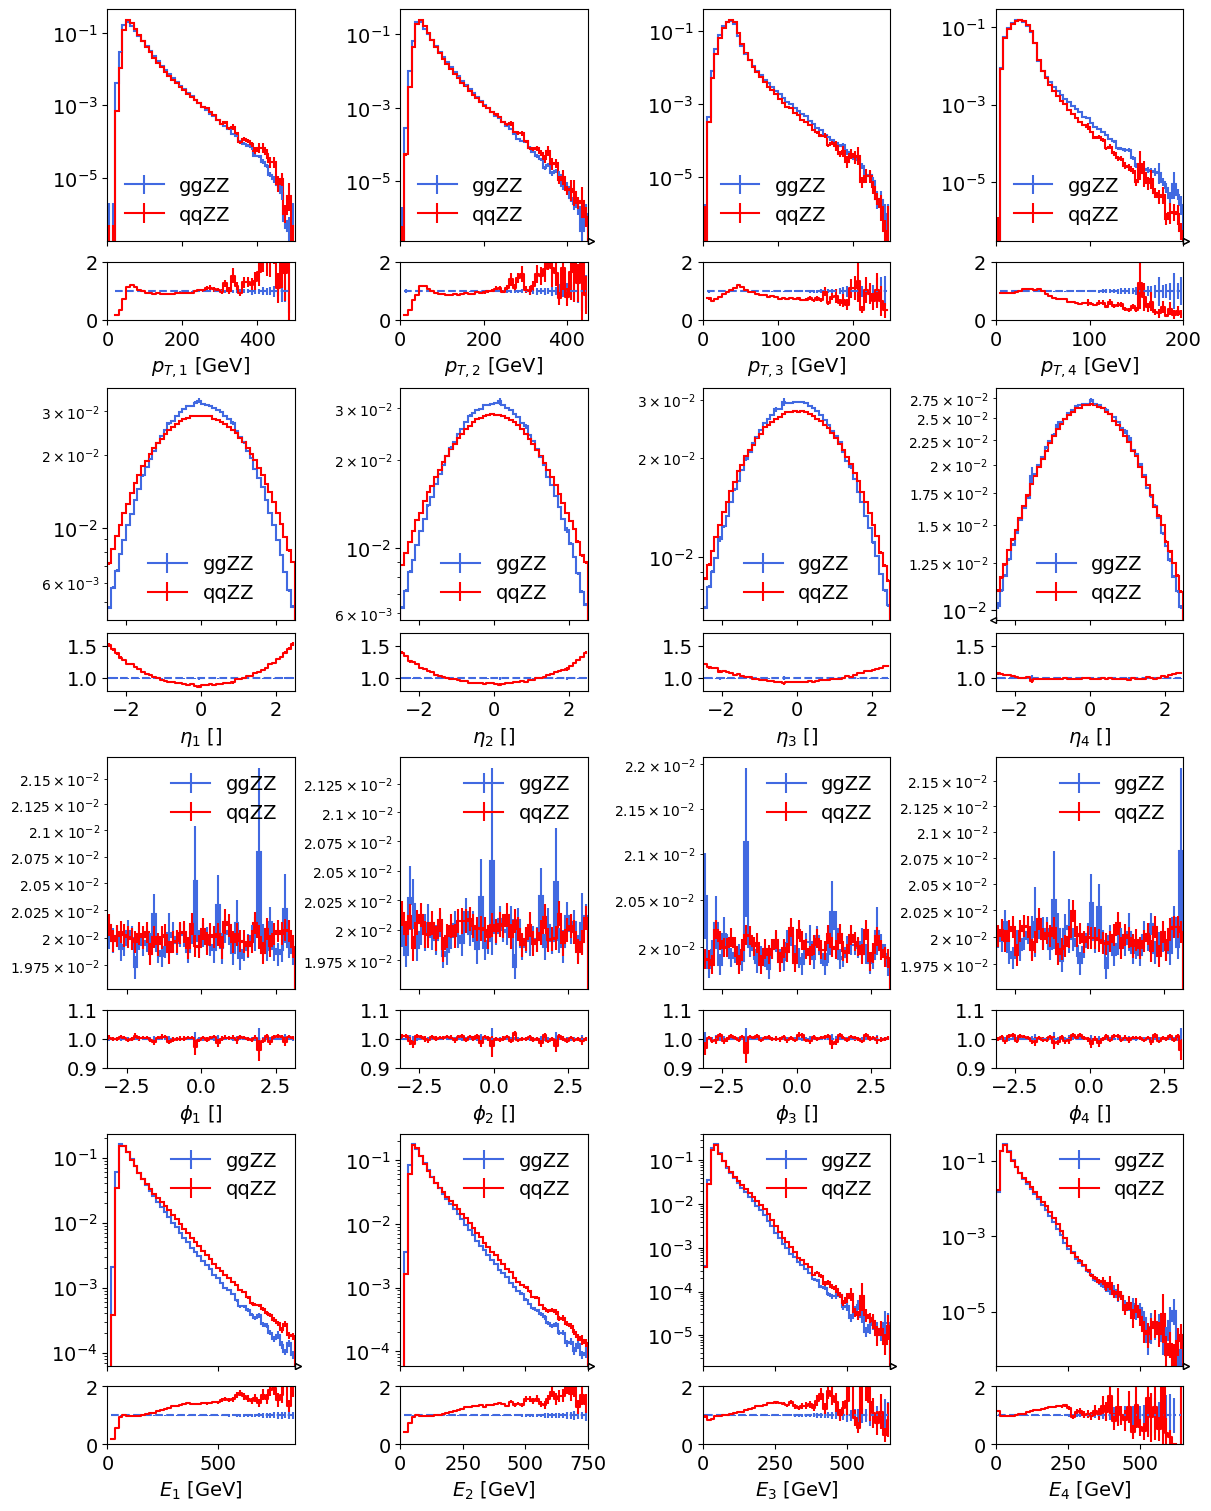

In [7]:
fig, axes = plt.subplots(8,4, gridspec_kw={'height_ratios': [4,1,4,1,4,1,4,1], 'wspace': 0, 'hspace': 0}, figsize=(12,15), layout='constrained')

gen_plot(0, axes[:2,0], f'$p_{{T,1}}$ [GeV]', (0,500), 50)
gen_plot(4, axes[:2,1], f'$p_{{T,2}}$ [GeV]', (0,450), 50)
gen_plot(8, axes[:2,2], f'$p_{{T,3}}$ [GeV]', (0,250), 50)
gen_plot(12, axes[:2,3], f'$p_{{T,4}}$ [GeV]', (0,200), 50)

gen_plot(1, axes[2:4,0], f'$\eta_{{1}}$ []', (-2.5,2.5), 50, r_lim=[0.8,1.7])
gen_plot(5, axes[2:4,1], f'$\eta_{{2}}$ []', (-2.5,2.5), 50, r_lim=[0.8,1.7])
gen_plot(9, axes[2:4,2], f'$\eta_{{3}}$ []', (-2.5,2.5), 50, r_lim=[0.8,1.7])
gen_plot(13, axes[2:4,3], f'$\eta_{{4}}$ []', (-2.5,2.5), 50, r_lim=[0.8,1.7])

gen_plot(2, axes[4:6,0], f'$\phi_{{1}}$ []', (-np.pi,np.pi), 50, r_lim=[0.9,1.1])
gen_plot(6, axes[4:6,1], f'$\phi_{{2}}$ []', (-np.pi,np.pi), 50, r_lim=[0.9,1.1])
gen_plot(10, axes[4:6,2], f'$\phi_{{3}}$ []', (-np.pi,np.pi), 50, r_lim=[0.9,1.1])
gen_plot(14, axes[4:6,3], f'$\phi_{{4}}$ []', (-np.pi,np.pi), 50, r_lim=[0.9,1.1])

gen_plot(3, axes[6:,0], f'$E_{{1}}$ [GeV]', (0,850), 50)
gen_plot(7, axes[6:,1], f'$E_{{2}}$ [GeV]', (0,750), 50)
gen_plot(11, axes[6:,2], f'$E_{{3}}$ [GeV]', (0,650), 50)
gen_plot(15, axes[6:,3], f'$E_{{4}}$ [GeV]', (0,650), 50)

#plt.tight_layout()
plt.show()

/tmp/ipykernel_2714817/843586039.py:19: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_ggZZ.axes[0].centers, h_ggZZ.values()/h_ggZZ.values(), yerr=np.sqrt(h_ggZZ.variances())/h_ggZZ.values(), drawstyle='steps-mid', linestyle='--', color='royalblue')
/tmp/ipykernel_2714817/843586039.py:20: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_qqZZ.axes[0].centers, h_qqZZ.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_qqZZ.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_qqZZ.values()/h_ggZZ.values()**2)**2), drawstyle='steps-mid', color='red')


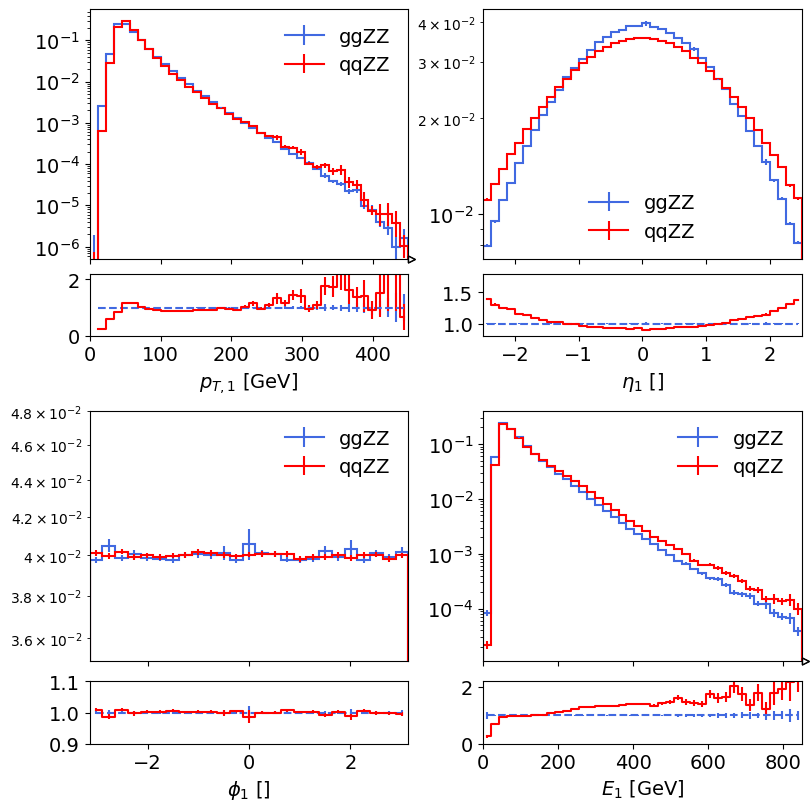

In [ ]:
fig, axes = plt.subplots(4,2, gridspec_kw={'height_ratios': [4,1,4,1], 'hspace': 0.0, 'wspace': 0.0},figsize=(8,8), layout='constrained')

gen_plot(4, axes[0:2,0], f'$p_{{T,2}}$ [GeV]', (0,450), 40, r_lim=[0,2.2])
gen_plot(5, axes[0:2,1], f'$\eta_{{2}}$ []', (-2.5,2.5), 40, r_lim=[0.8,1.8])
gen_plot(6, axes[2:,0], f'$\phi_{{2}}$ []', (-np.pi,np.pi), 25, r_lim=[0.9,1.1])
gen_plot(7, axes[2:,1], f'$E_{{2}}$ [GeV]', (0,850), 40, r_lim=[0,2.2])

axes[2,0].set_ylim(3.5e-2,4.8e-2)

#plt.tight_layout()
plt.show()